Copyright © 2024, Andrea Mastropietro. All rights reserved.

This code is licensed under the MIT License.

See the LICENSE file in the project root for more information.

## Shapley value distribution analysis
This notebook contains code for the analysis of the Shapley value distributions and their statistical significance.

In [ ]:
import os
# os.environ["http_proxy"] = "http://web-proxy.informatik.uni-bonn.de:3128"
# os.environ["https_proxy"] = "http://web-proxy.informatik.uni-bonn.de:3128"

Import libraries

In [2]:
# System and path management
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Configuration and YAML
import yaml

# Scientific computing and statistics
import numpy as np
import torch
from scipy.spatial.distance import directed_hausdorff
import scipy.stats as stats

# Data handling
import pandas as pd

# Plotting and visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Project-specific imports
from src.difflinker.lightning import DDPM
from src.difflinker.datasets import get_dataloader

In [3]:
EXPLANATIONS_FOLDER = "../results/explanations/zinc_final_test/"

with open('../config.yml', 'r') as file:
    config = yaml.safe_load(file)

checkpoint = "../" + config['CHECKPOINT']
DATA_FOLDER = "../" + config['DATA_FOLDER']
DATASET_NAME = config['DATASET_NAME']
keep_frames = int(config['KEEP_FRAMES'])
device = config['DEVICE'] if torch.cuda.is_available() else 'cpu'
SEED = int(config['SEED'])
NUM_SAMPLES = int(config['NUM_SAMPLES'])

SEED_LIST = [42,1240,14085]

model = DDPM.load_from_checkpoint(checkpoint, map_location=device)

model.val_data_prefix = DATASET_NAME

print(f"Running device: {device}")

model.data_path = DATA_FOLDER

model = model.eval().to(device)
model.setup(stage='val')
dataloader = get_dataloader(
    model.val_dataset,
    batch_size=1
)

/home/mastropietro/anaconda3/envs/diff_explainer/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Lightning automatically

Running device: cuda:7


/home/mastropietro/Repositories/DiffSHAPer/src/difflinker/datasets.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.data = torch.load(dataset_path, map_location=dev

Load data samples for fragment, linker and anchor indices

In [4]:
data_list = []
sampled = 0
data_dict = {}
for data in dataloader:
    if sampled < NUM_SAMPLES:
        data_list.append(data)
        sampled += 1

for i in range(len(data_list)):
    data_dict[i] = {}
    data_dict[i]["fragment_mask"] = data_list[i]['fragment_mask'].squeeze(0)
    data_dict[i]["linker_mask"] = data_list[i]['linker_mask'].squeeze(0)
    data_dict[i]["anchors"] = data_list[i]['anchors'].squeeze(0)

Read coordinates of generated linkers

In [5]:
for seed in SEED_LIST:
    for i in range(NUM_SAMPLES):
        with open(f"{EXPLANATIONS_FOLDER}explanations_seed_{str(seed)}/mapping/graphs/{i}/{i}_0_.xyz", "r") as f:
            num_atoms = int(f.readline().strip())
            f.readline()
            positions = []*num_atoms
            for line in f:
                row = line.strip().split(" ")[1:]
                coords = [float(x) for x in row]
                positions.append(coords)
            dict_key_name = f"positions_{seed}"
            data_dict[i][dict_key_name] = positions

In [6]:
#compute average hausdorff distance over the seeds for each sample
for i in range(NUM_SAMPLES):
    hausdorff_distances = []
    linker_coords_list = []
    for seed in SEED_LIST:
        coords = np.array(data_dict[i][f"positions_{seed}"])
        linker_mask = data_dict[i]["linker_mask"].cpu().numpy().squeeze().astype(bool)
        linker_coords = coords[linker_mask]
        linker_coords_list.append(linker_coords)
    
    # Compute Hausdorff distances for all possible pairs
    for j in range(len(linker_coords_list)):
        for k in range(j+1, len(linker_coords_list)):
            # Compute directed Hausdorff distances in both directions
            h1 = directed_hausdorff(linker_coords_list[j], linker_coords_list[k])[0]
            h2 = directed_hausdorff(linker_coords_list[k], linker_coords_list[j])[0]
            # Hausdorff distance is the maximum of the two directed distances
            hausdorff_distance = max(h1, h2)
            hausdorff_distances.append(hausdorff_distance)
    
    data_dict[i]["average_hausdorff_distance"] = sum(hausdorff_distances)/len(hausdorff_distances)

In [7]:
#print the samples for whihch the average hausdorff distance is less than 1
samples_with_similar_linkers = []
samples_with_different_linkers = []

for i in range(NUM_SAMPLES):
    if data_dict[i]['average_hausdorff_distance'] < 1:
        samples_with_similar_linkers.append(i)
        
    if data_dict[i]['average_hausdorff_distance'] > 3:
        samples_with_different_linkers.append(i)
        

Read Shapley values for similar linkers

In [8]:
#load shapley values
shapley_values_similar_dict = {}
shapley_values_all_dict = {}
shapley_values_different_dict = {}
for i in range(NUM_SAMPLES):
    shapley_values_all_dict[i] = []
    if i in samples_with_similar_linkers:
        shapley_values_similar_dict[i] = []
    if i in samples_with_different_linkers:
        shapley_values_different_dict[i] = []
    for seed in SEED_LIST:
        shapley_values_seed = []
        with open(f"{EXPLANATIONS_FOLDER}explanations_seed_{str(seed)}/shapley_values/shapley_values_atoms_{i}.txt", "r") as f:
            f.readline()
            f.readline()
            
            for line in f:
                if line == "\n":
                    break
                row = line.strip().split(",")
                shapley_values_seed.append(float(row[1]))
        shapley_values_all_dict[i].append(shapley_values_seed)
        if i in samples_with_similar_linkers:
            shapley_values_similar_dict[i].append(shapley_values_seed)
        if i in samples_with_different_linkers:
            shapley_values_different_dict[i].append(shapley_values_seed)

Plot Shapley value distribution for similar linkers

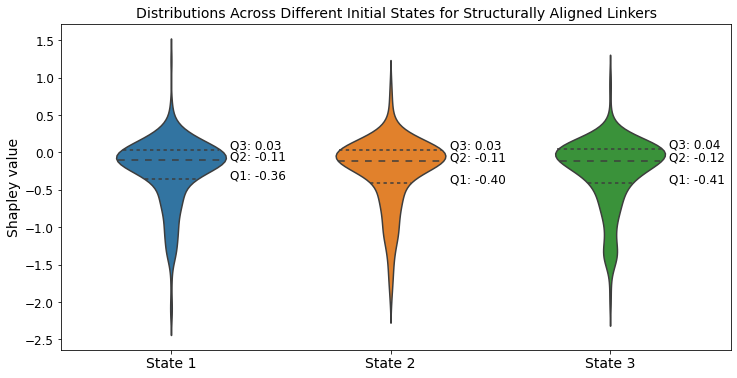

In [9]:
# Prepare data for plotting
shapley_values_all = []
seeds_all = []
samples_all = []

for sample, shapley_values_list in shapley_values_similar_dict.items():
    for seed_index, shapley_values in enumerate(shapley_values_list):
        shapley_values_all.extend(shapley_values)
        seeds_all.extend([SEED_LIST[seed_index]] * len(shapley_values))
        samples_all.extend([sample] * len(shapley_values))

# Create a DataFrame for plotting
plot_data = pd.DataFrame({
    'Shapley value': shapley_values_all,
    'Seed': seeds_all,
    'Sample': samples_all
})

# Plot the violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='Seed', y='Shapley value', data=plot_data, inner="quartile", scale="width", width=0.5)
plt.title('Distributions Across Different Initial States for Structurally Aligned Linkers', fontsize=14)
plt.xticks(ticks=[0, 1, 2], labels=["State 1", "State 2", "State 3"], fontsize=14)
plt.yticks(fontsize=12)
plt.xlabel(None)
plt.ylabel('Shapley value', fontsize=14)

seed_mapping = {seed: idx for idx, seed in enumerate(SEED_LIST)}

# Compute quartiles for each seed
quartiles = plot_data.groupby('Seed')['Shapley value'].quantile([0.25, 0.5, 0.75]).unstack()

# Print quartiles on the plot
for seed in SEED_LIST:
    q25, q50, q75 = quartiles.loc[seed]
    plt.text(seed_mapping[seed] + 0.27, q25, f'Q1: {q25:.2f}', color='black', fontsize=12)
    plt.text(seed_mapping[seed] + 0.27, q50, f'Q2: {q50:.2f}', color='black', fontsize=12)
    plt.text(seed_mapping[seed] + 0.27, q75 + 0.02, f'Q3: {q75:.2f}', color='black', fontsize=12)
    plt.xlim(right=2.55)

plt.savefig(f"../results/plots/shapley_value_distrubution_analysis/distribution_aligned_linkers.png", dpi=300)
plt.savefig(f"../results/plots/shapley_value_distrubution_analysis/distribution_aligned_linkers.pdf", dpi=300)

Plot Shapley value distribution for different the linkers

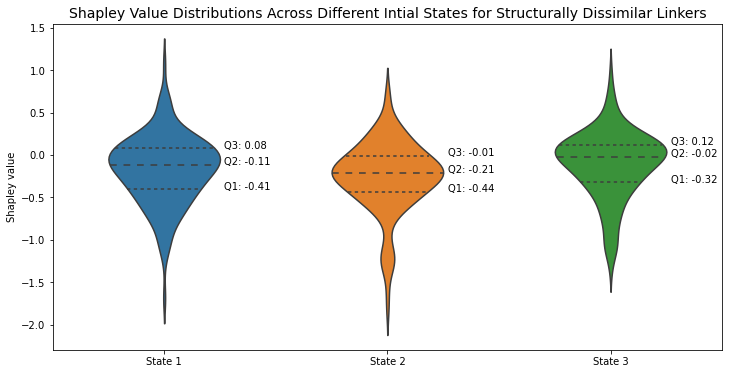

In [10]:
# Prepare data for plotting
#get shapley values for different samples
shapley_values_all = []
seeds_all = []
samples_all = []

for sample, shapley_values_list in shapley_values_different_dict.items():
    for seed_index, shapley_values in enumerate(shapley_values_list):
        shapley_values_all.extend(shapley_values)
        seeds_all.extend([SEED_LIST[seed_index]] * len(shapley_values))
        samples_all.extend([sample] * len(shapley_values))

# Create a DataFrame for plotting
plot_data = pd.DataFrame({
    'Shapley value': shapley_values_all,
    'Seed': seeds_all,
    'Sample': samples_all
})

# Plot the violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='Seed', y='Shapley value', data=plot_data, inner="quartile", scale="width", width=0.5)
plt.title('Shapley Value Distributions Across Different Intial States for Structurally Dissimilar Linkers', fontsize=14)
plt.xticks(ticks=[0, 1, 2], labels=["State 1", "State 2", "State 3"])
plt.xlabel(None)

seed_mapping = {seed: idx for idx, seed in enumerate(SEED_LIST)}

# Compute quartiles for each seed
quartiles = plot_data.groupby('Seed')['Shapley value'].quantile([0.25, 0.5, 0.75]).unstack()

# Print quartiles on the plot
for seed in SEED_LIST:
    q25, q50, q75 = quartiles.loc[seed]
    plt.text(seed_mapping[seed] + 0.27, q25, f'Q1: {q25:.2f}', color='black', fontsize=10)
    plt.text(seed_mapping[seed] + 0.27, q50, f'Q2: {q50:.2f}', color='black', fontsize=10)
    plt.text(seed_mapping[seed] + 0.27, q75, f'Q3: {q75:.2f}', color='black', fontsize=10)

plt.savefig(f"../results/plots/shapley_value_distrubution_analysis/distribution_dissimilar_linkers.png", dpi=300)
plt.savefig(f"../results/plots/shapley_value_distrubution_analysis/distribution_dissimilar_linkers.pdf", dpi=300)

Distrubution of Shapley values for all the linkers

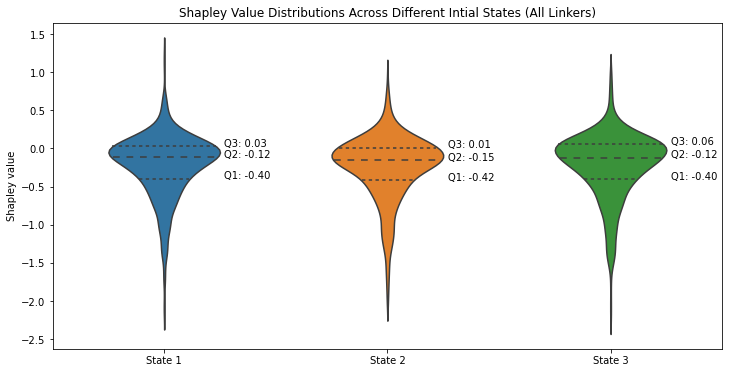

In [11]:
# Prepare data for plotting
#get shapley values for different samples
shapley_values_all = []
seeds_all = []
samples_all = []

for sample, shapley_values_list in shapley_values_all_dict.items():
    for seed_index, shapley_values in enumerate(shapley_values_list):
        shapley_values_all.extend(shapley_values)
        seeds_all.extend([SEED_LIST[seed_index]] * len(shapley_values))
        samples_all.extend([sample] * len(shapley_values))

# Create a DataFrame for plotting
plot_data = pd.DataFrame({
    'Shapley value': shapley_values_all,
    'Seed': seeds_all,
    'Sample': samples_all
})

# Plot the violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='Seed', y='Shapley value', data=plot_data, inner="quartile", scale="width", width=0.5)
plt.title('Shapley Value Distributions Across Different Intial States (All Linkers)')
plt.xticks(ticks=[0, 1, 2], labels=["State 1", "State 2", "State 3"])
plt.xlabel(None)

seed_mapping = {seed: idx for idx, seed in enumerate(SEED_LIST)}

# Compute quartiles for each seed
quartiles = plot_data.groupby('Seed')['Shapley value'].quantile([0.25, 0.5, 0.75]).unstack()

# Print quartiles on the plot
for seed in SEED_LIST:
    q25, q50, q75 = quartiles.loc[seed]
    plt.text(seed_mapping[seed] + 0.27, q25, f'Q1: {q25:.2f}', color='black', fontsize=10)
    plt.text(seed_mapping[seed] + 0.27, q50, f'Q2: {q50:.2f}', color='black', fontsize=10)
    plt.text(seed_mapping[seed] + 0.27, q75, f'Q3: {q75:.2f}', color='black', fontsize=10)

plt.savefig(f"../results/plots/shapley_value_distrubution_analysis/distribution_all_linkers.png", dpi=300)
plt.savefig(f"../results/plots/shapley_value_distrubution_analysis/distribution_all_linkers.pdf", dpi=300)

### Inspecting Shapley value significance

Inspecting difference between the Hsapley valus for different initial states

In [12]:
# Prepare data for the Kruskal-Wallis H Test
shapley_values_by_seed = [plot_data[plot_data['Seed'] == seed]['Shapley value'].values for seed in SEED_LIST]

# Perform the Kruskal-Wallis H Test
stat, p_value = stats.kruskal(*shapley_values_by_seed)

print(f'Kruskal-Wallis H test statistic: {stat}')
print(f'p-value: {p_value}')

# Interpret the result
alpha = 0.05
if p_value < alpha:
    print("There are significant differences in Shapley values across different seeds (reject H0). The initial state has a significant impact on Shapley values.")
else:
    print("There are no significant differences in Shapley values across different seeds (fail to reject H0). The initial state does not have a significant impact on Shapley values.")

Kruskal-Wallis H test statistic: 3.1184731059101978
p-value: 0.21029656021798795
There are no significant differences in Shapley values across different seeds (fail to reject H0). The initial state does not have a significant impact on Shapley values.


In [13]:
shapley_values_chosen_seed = plot_data[plot_data['Seed'] == 42]['Shapley value'].values

Test if Shapley values statistically different from zero

In [14]:

# Check if the data is normally distributed first
shapiro_stat, shapiro_p = stats.shapiro(shapley_values_chosen_seed)
print(f"Shapiro-Wilk test: statistic={shapiro_stat}, p-value={shapiro_p}")

# Choose appropriate test based on normality
alpha = 0.05
if shapiro_p > alpha:  # Data is normally distributed
    # Use one-sample t-test
    t_stat, t_p = stats.ttest_1samp(shapley_values_chosen_seed, 0)
    print(f"One-sample t-test: statistic={t_stat}, p-value={t_p}")
    if t_p < alpha:
        print("The values are significantly different from 0 (not random noise).")
    else:
        print("The values are not significantly different from 0 (could be random).")
else:  
    # Data is not normally distributed - use non-parametric test
    w_stat, w_p = stats.wilcoxon(shapley_values_chosen_seed)
    print(f"Wilcoxon signed-rank test: statistic={w_stat}, p-value={w_p}")
    if w_p < alpha:
        print("The values are significantly different from 0 (not random noise).")
    else:
        print("The values are not significantly different from 0 (could be random).")

Shapiro-Wilk test: statistic=0.9233610033988953, p-value=4.53619495176976e-17
Wilcoxon signed-rank test: statistic=39995.0, p-value=2.641448828201941e-34
The values are significantly different from 0 (not random noise).


Test against uniform and normal random distribution

In [15]:
# Test against a uniform distribution
ks_uniform_stat, ks_uniform_p = stats.kstest(
    shapley_values_chosen_seed, 
    'uniform', 
    args=(min(shapley_values_chosen_seed), max(shapley_values_chosen_seed)-min(shapley_values_chosen_seed))
)
print(f"Kolmogorov-Smirnov test (uniform): statistic={ks_uniform_stat}, p-value={ks_uniform_p}")
if ks_uniform_p < 0.05:
    print("The values are not uniformly distributed (not random uniform).")
else:
    print("The values appear to be uniformly distributed.")

# Test against a normal distribution
ks_norm_stat, ks_norm_p = stats.kstest(
    (shapley_values_chosen_seed - np.mean(shapley_values_chosen_seed)) / np.std(shapley_values_chosen_seed), 
    'norm'
)
print(f"Kolmogorov-Smirnov test (normal): statistic={ks_norm_stat}, p-value={ks_norm_p}")
if ks_norm_p < 0.05:
    print("The values are not normally distributed (not random normal).")
else:
    print("The values appear to be normally distributed.")

Kolmogorov-Smirnov test (uniform): statistic=0.3161451618913505, p-value=1.0645921339992811e-54
The values are not uniformly distributed (not random uniform).
Kolmogorov-Smirnov test (normal): statistic=0.11931620725255127, p-value=5.035910262385138e-08
The values are not normally distributed (not random normal).


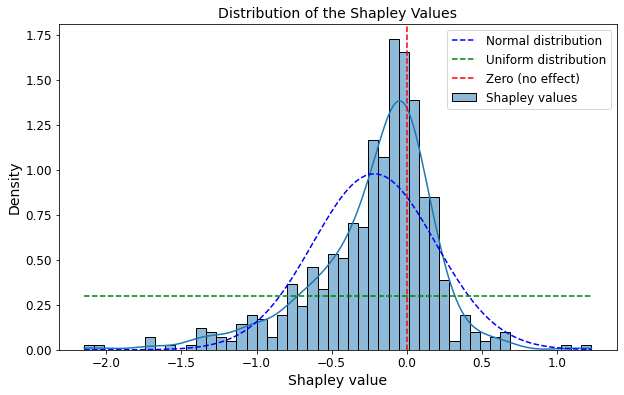

In [16]:
# Calculate mean and standard deviation of the Shapley values
mean_shapley = np.mean(shapley_values_chosen_seed)
std_shapley = np.std(shapley_values_chosen_seed)

# Generate a normal distribution with the same mean and std dev
x = np.linspace(min(shapley_values_chosen_seed), max(shapley_values_chosen_seed), 100)
normal_dist = stats.norm.pdf(x, mean_shapley, std_shapley)

# Generate a uniform distribution with the same range
uniform_dist = stats.uniform.pdf(x, min(shapley_values_chosen_seed), max(shapley_values_chosen_seed) - min(shapley_values_chosen_seed))

plt.figure(figsize=(10, 6))
sns.histplot(shapley_values_chosen_seed, kde=True, stat="density", bins=50, label='Shapley values')
plt.plot(x, normal_dist, color='blue', linestyle='--', label='Normal distribution')
plt.plot(x, uniform_dist, color='green', linestyle='--', label='Uniform distribution')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', label='Zero (no effect)')
plt.title('Distribution of the Shapley Values', fontsize=14)
plt.xlabel('Shapley value', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(fontsize=12)

plt.savefig(f"../results/plots/shapley_value_distrubution_analysis/shapley_value_distribution_againts_uniform_normal.png", dpi=300, bbox_inches='tight')
plt.savefig(f"../results/plots/shapley_value_distrubution_analysis/shapley_value_distribution_againts_uniform_normal.pdf", dpi=300, bbox_inches='tight')